In [ ]:
include("CRD_STA.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems
using DelimitedFiles
using ProgressMeter

In [ ]:
function BF(N_cheb,Ro,Tw,Mr)
    gamma = 1.4
    sigma = 0.72
    Co = 2 - Ro - Ro^2
    u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    return F,G,H,T,rho,x,lam,kappa,D,D2
end
function eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
    sigma = 0.72
    gamma = 1.4
    # if Ro == -1
    #    A0,A1,A2 = Spatial_mode_BEK(-F,-G,-H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2)
    # else 
    A0,A1,A2 = Spatial_mode_BEK1(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2)
    # end
    A0,A1,A2 = boudary_condition(A0,A1,A2,N_cheb)
    nep = PEP([A0,A1,A2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-12)
    # eigval = conj(eigval)
    return eigval
end

In [ ]:
N_cheb = 199
Ro = -1
Tw = 1.2
Mr = 0.6
gamma = 1.4
sigma = 0.72
Co = 2-Ro-Ro^2
be = 0.0462
num = 1
omega = 0
data = [0 0 0]
F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
R = 440.88
Ma = Mr/R
eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,0.13,num)

In [ ]:
critical_data = readdlm("ome=0.008_critical.dat")

In [ ]:
beta_initial_1 = 0
for i = 1 : 1 : size(critical_data,1)
    if critical_data[i,1] == Mr && critical_data[i,2] == Tw
        beta_initial_1 = critical_data[i,9]
        R_initial_1 = critical_data[i,7]
        beta_initial_2 = critical_data[i,5]
        R_initial_2 = critical_data[i,3]
        c_1 = critical_data[i,10]
        c_2 = critical_data[i,6]
        break
    end
end
beta_initial_1

In [108]:
function max_rate(Tw,omega,Mr)
    N_cheb = 199
    Ro = -1
    gamma = 1.4
    sigma = 0.72
    Co = 2-Ro-Ro^2
    num = 1
    omega = 0.008
    F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
    temp = [0 0 0 0 0]
    critical_data = readdlm("ome=0.0_critical.dat")
    beta_initial_1 = 0
    R_initial_1    = 0
    beta_initial_2 = 0
    R_initial_2    = 0
    c_1            = 0
    c_2            = 0
    max_rate_1     = 0
    max_rate_2     = 0
    max_beta_1     = 0
    max_beta_2     = 0
    for i = 1 : 1 : size(critical_data,1)
        if critical_data[i,1] == Mr && critical_data[i,2] == Tw
            # beta_initial_1 = critical_data[i,9]
            # R_initial_1    = critical_data[i,7]
            beta_initial_2 = critical_data[i,5]
            R_initial_2    = critical_data[i,3]
            # c_1            = critical_data[i,10]
            c_2            = critical_data[i,6]
            break
        end
    end
    # for be = beta_initial_1-0.01 : 0.0005 : 0.1
    #     R = R_initial_1 + 25
    #     Ma = Mr/R
    #     eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c_1,num)
    #     temp = [temp;[Mr Tw be imag(eigval) real(eigval)]]
    #     writedlm("data.dat",temp)
    #     if size(temp,1) > 3 && temp[end,4] > temp[2,4] 
    #         index = findmin(temp[2:end,4])[2]
    #         max_rate_1 = temp[index,4]
    #         max_beta_1 = temp[index,3]
    #         temp = [0 0 0 0 0]
    #         break
    #     end
    # end
    for be = beta_initial_2 - 0.02 : 0.001: 0.2
        R = R_initial_2 + 25
        Ma = Mr/R
        eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c_2,num)
        temp = [temp;[Mr Tw be imag(eigval) real(eigval)]]
        writedlm("data.dat",temp)
        if size(temp,1) > 3 && temp[end,4] > temp[2,4] 
            index = findmin(temp[2:end,4])[2]
            max_rate_2 = temp[index,4]
            max_beta_2 = temp[index,3]
            temp = [0 0 0 0 0]
            break
        end
    end
    data = [Mr Tw max_beta_1 max_rate_1 max_beta_2 max_rate_2]
    return data
end

max_rate (generic function with 1 method)

In [109]:
data_all = [0 0 0 0 0 0]
critical_data = readdlm("ome=0.0_critical.dat")
for Tw = 0.8 : 0.1 : 1.2
    for Mr = 0.3 : 0.3 : 1.2
        data = max_rate(Tw,omega,Mr)
        data_all = [data_all;data]
    end
end
writedlm("max_data.dat",data_all[2:end,:])

In [ ]:
using BSplineKit
using Plots

In [110]:
max_data = readdlm("max_data.dat") 
Ma_03 = max_data[1:4:end,:]
Ma_06 = max_data[2:4:end,:]
Ma_09 = max_data[3:4:end,:]
Ma_12 = max_data[4:4:end,:]
Ma_03_interp = BSplineKit.interpolate(Ma_03[:,2],Ma_03[:,4],BSplineOrder(4),Natural())
Ma_06_interp = BSplineKit.interpolate(Ma_06[:,2],Ma_06[:,4],BSplineOrder(4),Natural())
Ma_09_interp = BSplineKit.interpolate(Ma_09[:,2],Ma_09[:,4],BSplineOrder(4),Natural())
Ma_12_interp = BSplineKit.interpolate(Ma_12[:,2],Ma_12[:,4],BSplineOrder(4),Natural())
Tw_range = range(0.8,stop=1.2,length=101)
Ma_03_interp_data = Ma_03_interp.(Tw_range)
Ma_06_interp_data = Ma_06_interp.(Tw_range)
Ma_09_interp_data = Ma_09_interp.(Tw_range)
Ma_12_interp_data = Ma_12_interp.(Tw_range)

101-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [111]:
Ma_03_interp_2 = BSplineKit.interpolate(Ma_03[:,2],Ma_03[:,6],BSplineOrder(4),Natural())
Ma_06_interp_2 = BSplineKit.interpolate(Ma_06[:,2],Ma_06[:,6],BSplineOrder(4),Natural())
Ma_09_interp_2 = BSplineKit.interpolate(Ma_09[:,2],Ma_09[:,6],BSplineOrder(4),Natural())
Ma_12_interp_2 = BSplineKit.interpolate(Ma_12[:,2],Ma_12[:,6],BSplineOrder(4),Natural())
Tw_range = range(0.8,stop=1.2,length=101)
Ma_03_interp_data_2 = Ma_03_interp_2.(Tw_range)
Ma_06_interp_data_2 = Ma_06_interp_2.(Tw_range)
Ma_09_interp_data_2 = Ma_09_interp_2.(Tw_range)
Ma_12_interp_data_2 = Ma_12_interp_2.(Tw_range)

101-element Vector{Float64}:
 -0.007895915467158366
 -0.00789276130926382
 -0.007889624964781758
 -0.00788652424712466
 -0.007883476969705013
 -0.007880500945935297
 -0.007877613989227997
 -0.007874833912995592
 -0.00787217853065057
 -0.007869665655605412
  ⋮
 -0.007790086353322883
 -0.007785935757927152
 -0.007781810507994296
 -0.007777706982743906
 -0.007773621561395569
 -0.007769550623168873
 -0.007765490547283411
 -0.00776143771295877
 -0.00775738849941454

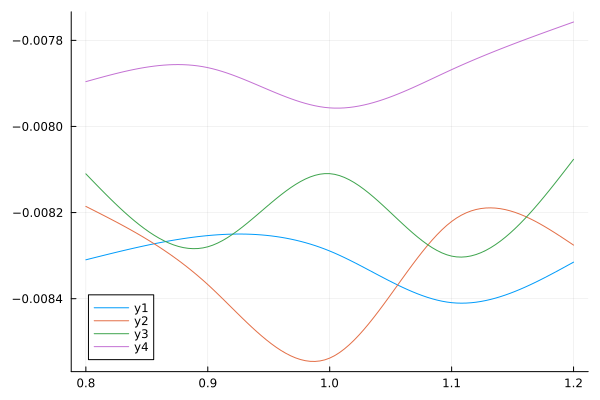

In [112]:
plot(Tw_range , Ma_03_interp_data_2)
plot!(Tw_range, Ma_06_interp_data_2)
plot!(Tw_range, Ma_09_interp_data_2)
plot!(Tw_range, Ma_12_interp_data_2)

In [93]:
data_all = [0.3*ones(101,1) Tw_range Ma_03_interp_data Ma_03_interp_data_2;
            0.6*ones(101,1) Tw_range Ma_06_interp_data Ma_06_interp_data_2;
            0.9*ones(101,1) Tw_range Ma_09_interp_data Ma_09_interp_data_2;
            1.2*ones(101,1) Tw_range Ma_12_interp_data Ma_12_interp_data_2] 

404×4 Matrix{Float64}:
 0.3  0.8    -0.00951266  -0.00201769
 0.3  0.804  -0.00954152  -0.00201564
 0.3  0.808  -0.00957037  -0.0020136
 0.3  0.812  -0.00959921  -0.00201154
 0.3  0.816  -0.00962804  -0.00200947
 0.3  0.82   -0.00965685  -0.00200737
 0.3  0.824  -0.00968564  -0.00200524
 0.3  0.828  -0.00971441  -0.00200308
 0.3  0.832  -0.00974315  -0.00200088
 0.3  0.836  -0.00977185  -0.00199864
 ⋮                        
 1.2  1.168  -0.0104336   -0.00186289
 1.2  1.172  -0.0104455   -0.00186774
 1.2  1.176  -0.0104574   -0.00187259
 1.2  1.18   -0.0104693   -0.00187744
 1.2  1.184  -0.0104811   -0.00188229
 1.2  1.188  -0.010493    -0.00188714
 1.2  1.192  -0.0105048   -0.00189198
 1.2  1.196  -0.0105166   -0.00189683
 1.2  1.2    -0.0105285   -0.00190167

In [94]:
writedlm("max_data_intep.dat",data_all)